# 04 · Modelo, "¿qué pasa si…?", producto y segmentos

1. **Complemento de H3:** ¿qué características se asocian a poder pagar? (regresión logística ponderada)
2. **¿Qué pasa si…?** Medidas que puede tomar el banco, en hogares
3. **¿Qué lo empeora?** Riesgos del contexto
4. **Diseño de producto:** plazo × % financiado
5. **Segmentos de "casi elegibles":** a quién apuntar primero
6. **Escala del programa de fondeo**

In [1]:
import sys, json, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

import config
import viz
import analysis as A
from affordability import ETAPAS, GBA, Producto, cargar_inquilinos, embudo, evaluar, parametros_mercado
from formato import fmt_cantidad, fmt_hogares, fmt_mes, fmt_monto, fmt_pct, fmt_decimal

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 30)

con = duckdb.connect(str(config.DB_PATH), read_only=True)
m = parametros_mercado(con)
h = cargar_inquilinos(con)
base = Producto()
ev = evaluar(h, m, base)
ev["zona"] = A.grupo_geografico(ev)
K = json.loads((config.PROCESSED / "resultados" / "kpis.json").read_text(encoding="utf-8"))
RAMPA = LinearSegmentedColormap.from_list("azul", ["#eef4fc"] + viz.BLUE_RAMP)

def tinta_sobre(valor, vmin, vmax):
    """Texto blanco sobre celdas oscuras y tinta sobre celdas claras (según luminancia del color de fondo)."""
    r, g, b, _ = RAMPA((valor - vmin) / (vmax - vmin))
    return "#ffffff" if 0.2126 * r + 0.7152 * g + 0.0722 * b < 0.45 else viz.INK
print(f"UVA ${m['uva']:,.2f} ({m['fecha_uva']}) · dólar minorista ${m['tc']:,.2f} ({m['fecha_tc']})")
print(f"Inquilinos con ingreso declarado: {len(h)} observaciones de {h.hogar_id.nunique()} hogares encuestados · representan {fmt_hogares(h.peso.sum())}")

UVA $2,116.04 (2026-09-13) · dólar minorista $1,531.73 (2026-09-11)
Inquilinos con ingreso declarado: 2028 observaciones de 1504 hogares encuestados · representan 1,2 millones hogares


## 1. ¿Qué características se asocian a pasar cuota y anticipo?

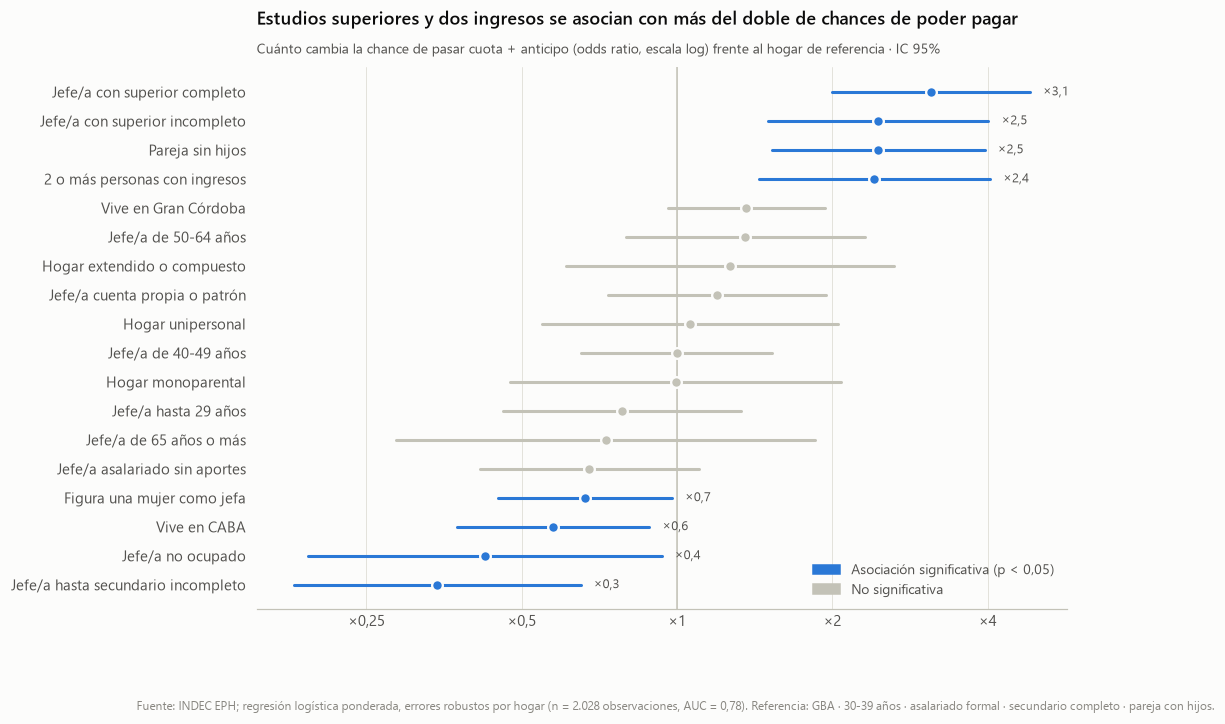

{'n_observaciones': 2028, 'n_hogares': 1504, 'positivos': 357, 'auc_ponderado': 0.7769529614946007, 'pseudo_r2_mcfadden': np.float64(0.16079938958921136), 'errores': 'robustos por conglomerado (hogar)', 'referencia': 'GBA · 30-39 años · asalariado formal · secundario completo · pareja con hijos'}


,etiqueta,odds_ratio,or_ic95_inf,or_ic95_sup,p_valor
11,Jefe/a con superior completo,3.11,2.00,4.83,0.00
12,Jefe/a con superior incompleto,2.45,1.50,4.01,0.00
15,Pareja sin hijos,2.45,1.52,3.94,0.00
17,2 o más personas con ingresos,2.41,1.44,4.04,0.00
2,Vive en Gran Córdoba,1.36,0.96,1.93,0.08
4,Jefe/a de 50-64 años,1.36,0.80,2.31,0.26
13,Hogar extendido o compuesto,1.27,0.61,2.63,0.53
8,Jefe/a cuenta propia o patrón,1.20,0.74,1.95,0.47
16,Hogar unipersonal,1.06,0.55,2.05,0.86
3,Jefe/a de 40-49 años,1.00,0.65,1.53,1.00


In [2]:
logit, info = A.logit_ponderado(ev)
ETIQ = {
 "dos_o_mas_perceptores": "2 o más personas con ingresos", "educacion_Superior completo": "Jefe/a con superior completo",
 "educacion_Superior incompleto": "Jefe/a con superior incompleto", "educacion_Hasta secundario incompleto": "Jefe/a hasta secundario incompleto",
 "mercado_Gran Córdoba": "Vive en Gran Córdoba", "mercado_CABA": "Vive en CABA",
 "situacion_Cuenta propia / patrón": "Jefe/a cuenta propia o patrón", "situacion_Asalariado informal": "Jefe/a asalariado sin aportes",
 "situacion_No ocupado": "Jefe/a no ocupado",
 "edad_Hasta 29": "Jefe/a hasta 29 años", "edad_40-49": "Jefe/a de 40-49 años", "edad_50-64": "Jefe/a de 50-64 años", "edad_65+": "Jefe/a de 65 años o más",
 "tipo_hogar_Pareja sin hijos": "Pareja sin hijos", "tipo_hogar_Unipersonal": "Hogar unipersonal", "tipo_hogar_Monoparental": "Hogar monoparental",
 "tipo_hogar_Extendido o compuesto": "Hogar extendido o compuesto", "jefatura_mujer": "Figura una mujer como jefa",
}
d = logit.assign(etiqueta=logit.variable.map(ETIQ)).sort_values("odds_ratio")
fig, ax = plt.subplots(figsize=(9.5, 6.4))
ax.axvline(1, color=viz.BASELINE, lw=1)
for i, r in enumerate(d.itertuples()):
    c = viz.BLUE if r.p_valor < 0.05 else viz.CONTEXT_GRAY
    ax.plot([r.or_ic95_inf, r.or_ic95_sup], [i, i], color=c, lw=2, solid_capstyle="round")
    ax.plot(r.odds_ratio, i, "o", color=c, ms=7, mec=viz.SURFACE, mew=1.5)
    if r.p_valor < 0.05:
        ax.text(r.or_ic95_sup * 1.06, i, f"×{fmt_decimal(r.odds_ratio)}", va="center", fontsize=8.5, color=viz.INK_2)
ax.set_yticks(range(len(d)), d.etiqueta)
ax.set_xscale("log")
ax.xaxis.set_major_locator(mtick.FixedLocator([0.25, 0.5, 1, 2, 4, 8]))
ax.xaxis.set_minor_locator(mtick.NullLocator())
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: "×" + fmt_decimal(v, 2).rstrip("0").rstrip(",")))
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.legend(handles=[Patch(color=viz.BLUE, label="Asociación significativa (p < 0,05)"), Patch(color=viz.CONTEXT_GRAY, label="No significativa")], loc="lower right")
ax.set_title("Estudios superiores y dos ingresos se asocian con más del doble de chances de poder pagar")
viz.subtitle(ax, "Cuánto cambia la chance de pasar cuota + anticipo (odds ratio, escala log) frente al hogar de referencia · IC 95%")
n_obs = f"{info['n_observaciones']:,}".replace(",", ".")
viz.source(fig, f"INDEC EPH; regresión logística ponderada, errores robustos por hogar (n = {n_obs} observaciones, AUC = {fmt_decimal(info['auc_ponderado'], 2)}). Referencia: {info['referencia']}.")
viz.save(fig, "04_logit_odds")
plt.show()
print(info)
d[["etiqueta", "odds_ratio", "or_ic95_inf", "or_ic95_sup", "p_valor"]].sort_values("odds_ratio", ascending=False)

**Lectura (complemento de H3, asociaciones y no causas):** con las demás características constantes, lo que más se asocia a poder pagar es un **jefe o jefa con superior completo (×3,1)**, **dos o más personas con ingresos (×2,4)** y ser **pareja sin hijos (×2,5)**. Vivir en **CABA** reduce la chance (×0,6), por el precio del m².

Que figure una **mujer como jefa** muestra una asociación negativa moderada (×0,7, IC 0,45–0,98). **No debe leerse como un efecto del género:** el modelo no incluye el ingreso (es lo que se busca explicar) ni variables como antigüedad, horas o brechas salariales; ese coeficiente resume diferencias de ingreso que las demás variables no capturan.

> Modelo explicativo, no de scoring individual. AUC 0,78; pesos normalizados; errores robustos por conglomerado (hogar).

## 2. ¿Qué pasa si…? Medidas que puede tomar el banco
**Rediseño pedido en el Checkpoint 3:** la versión anterior mostraba cambios porcentuales por "palanca" y no se entendía. Ahora cada fila es una **pregunta en lenguaje simple**, con **hogares** que se suman o se pierden y **por qué**.

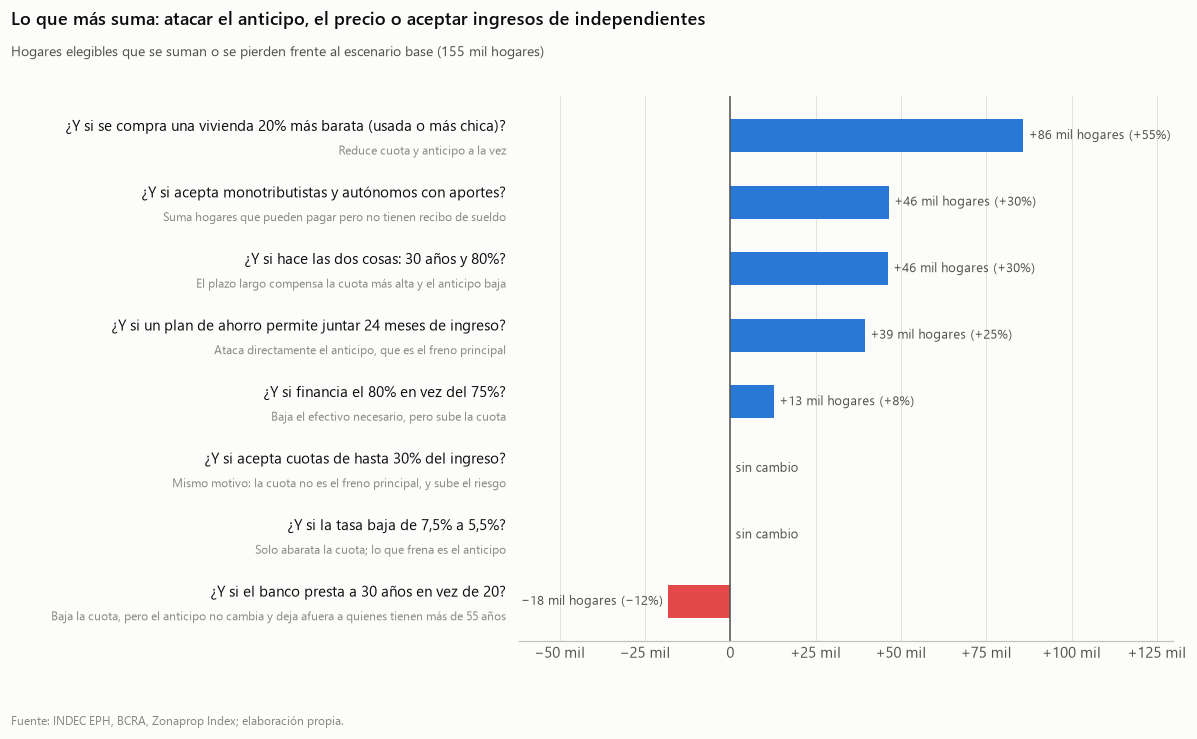

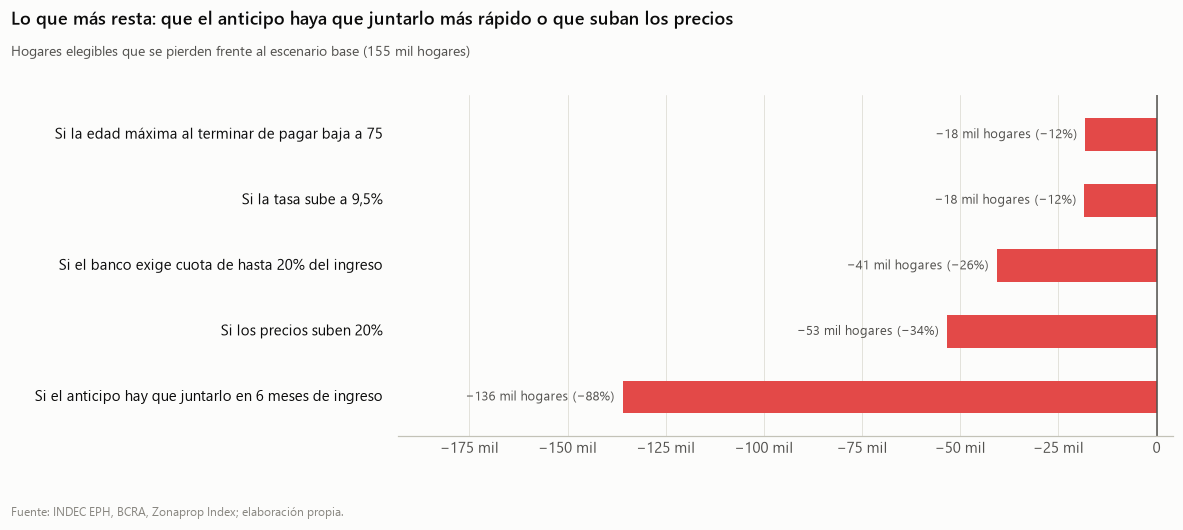

,pregunta,hogares_base,hogares,diferencia,diferencia_pct,por_que
0,¿Y si el banco presta a 30 años en vez de 20?,"154,793.14","136,628.67","-18,164.47",-11.73,"Baja la cuota, pero el anticipo no cambia y de..."
1,¿Y si financia el 80% en vez del 75%?,"154,793.14","167,594.30","12,801.17",8.27,"Baja el efectivo necesario, pero sube la cuota"
2,¿Y si hace las dos cosas: 30 años y 80%?,"154,793.14","200,951.53","46,158.40",29.82,El plazo largo compensa la cuota más alta y el...
3,"¿Y si la tasa baja de 7,5% a 5,5%?","154,793.14","154,793.14",0.00,0.00,Solo abarata la cuota; lo que frena es el anti...
4,¿Y si acepta cuotas de hasta 30% del ingreso?,"154,793.14","154,793.14",0.00,0.00,Mismo motivo: la cuota no es el freno principa...
5,¿Y si un plan de ahorro permite juntar 24 mese...,"154,793.14","194,261.81","39,468.67",25.50,"Ataca directamente el anticipo, que es el fren..."
6,¿Y si acepta monotributistas y autónomos con a...,"154,793.14","201,273.11","46,479.97",30.03,Suma hogares que pueden pagar pero no tienen r...
7,¿Y si se compra una vivienda 20% más barata (u...,"154,793.14","240,695.96","85,902.83",55.50,Reduce cuota y anticipo a la vez


,pregunta,hogares_base,hogares,diferencia,diferencia_pct,por_que
0,Si los precios suben 20%,"154,793.14","101,398.53","-53,394.61",-34.49,
1,"Si la tasa sube a 9,5%","154,793.14","136,420.09","-18,373.04",-11.87,
2,Si el banco exige cuota de hasta 20% del ingreso,"154,793.14","114,074.98","-40,718.16",-26.30,
3,Si el anticipo hay que juntarlo en 6 meses de ...,"154,793.14","18,777.58","-136,015.55",-87.87,
4,Si la edad máxima al terminar de pagar baja a 75,"154,793.14","136,628.67","-18,164.47",-11.73,


In [3]:
mejoras, riesgos = A.que_pasa_si(h, m, base)

def grafico_cambios(t, titulo, bajada, archivo, con_por_que=True):
    from matplotlib.transforms import blended_transform_factory
    t = t.sort_values("diferencia").reset_index(drop=True)
    alto = 0.62 * len(t) + 1.5
    fig, ax = plt.subplots(figsize=(11, alto))
    fig.subplots_adjust(left=0.43 if con_por_que else 0.33, right=0.97, top=1 - 0.95 / alto, bottom=0.55 / alto)
    y = np.arange(len(t))
    colores = [viz.BLUE if v > 0.5 else (viz.RED if v < -0.5 else viz.CONTEXT_GRAY) for v in t.diferencia]
    ax.barh(y, t.diferencia, color=colores, height=0.5)
    lo, hi = min(t.diferencia.min(), 0), max(t.diferencia.max(), 0)
    rango = hi - lo
    ax.set_xlim(lo - rango * (0.42 if lo < 0 else 0.03), hi + rango * (0.42 if hi > 0 else 0.03))
    etiquetas = blended_transform_factory(ax.transAxes, ax.transData)
    for yi, r in zip(y, t.itertuples()):
        signo = "+" if r.diferencia > 0.5 else ("−" if r.diferencia < -0.5 else "")
        texto = f"{signo}{fmt_cantidad(abs(r.diferencia))} hogares ({signo}{fmt_pct(abs(r.diferencia_pct), 0)})" if signo else "sin cambio"
        ax.text(r.diferencia + (rango * 0.015 if r.diferencia >= 0 else -rango * 0.015), yi, texto, va="center", ha="left" if r.diferencia >= 0 else "right", fontsize=8.5, color=viz.INK_2)
        ax.text(-0.02, yi + (0.13 if con_por_que else 0), r.pregunta, transform=etiquetas, ha="right", va="center", fontsize=9.5, color=viz.INK)
        if con_por_que:
            ax.text(-0.02, yi - 0.24, r.por_que, transform=etiquetas, ha="right", va="center", fontsize=8, color=viz.MUTED)
    ax.set_yticks([])
    ax.set_ylim(-0.6, len(t) - 0.4)
    ax.axvline(0, color=viz.INK_2, lw=1)
    ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: ("+" if v > 0 else "−" if v < 0 else "") + fmt_cantidad(abs(v))))
    fig.text(0.01, 1 - 0.18 / alto, titulo, fontsize=12, fontweight="semibold", color=viz.INK, ha="left", va="top")
    fig.text(0.01, 1 - 0.50 / alto, bajada, fontsize=9, color=viz.INK_2, ha="left", va="top")
    viz.source(fig, "INDEC EPH, BCRA, Zonaprop Index; elaboración propia.")
    viz.save(fig, archivo)
    plt.show()

base_hog = fmt_cantidad(mejoras.hogares_base.iloc[0])
grafico_cambios(mejoras, "Lo que más suma: atacar el anticipo, el precio o aceptar ingresos de independientes",
                f"Hogares elegibles que se suman o se pierden frente al escenario base ({base_hog} hogares)", "04_que_pasa_si")
grafico_cambios(riesgos, "Lo que más resta: que el anticipo haya que juntarlo más rápido o que suban los precios",
                f"Hogares elegibles que se pierden frente al escenario base ({base_hog} hogares)", "04_que_lo_empeora", con_por_que=False)
display(mejoras); display(riesgos)

**Lectura:** las medidas que más suman atacan el **efectivo necesario** o el **precio**: una vivienda 20% más barata (+86 mil hogares), aceptar **monotributistas y autónomos con aportes** (+46 mil), **30 años con 80% financiado** (+46 mil) o un **plan de ahorro** para el anticipo (+39 mil). Bajar la tasa o subir el tope de cuota, **solos, no suman**. El plazo largo **solo resta** (-18 mil) por la regla de edad.

## 3. Diseño de producto: plazo × % financiado

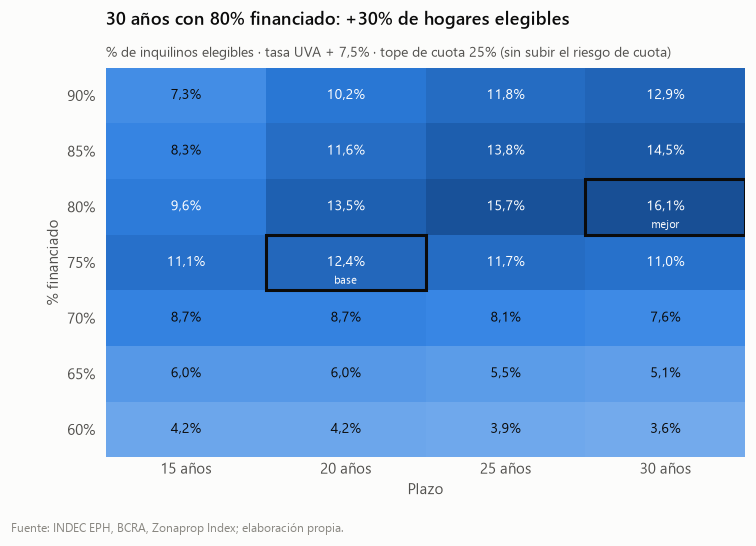

,plazo_anios,ltv,tope_cuota_ingreso,hogares,pct_elegible
53,30,0.85,0.30,"243,774.96",19.58
39,25,0.85,0.30,"235,794.80",18.94
23,20,0.80,0.30,"224,388.30",18.03
55,30,0.90,0.30,"220,726.43",17.73
41,25,0.90,0.30,"219,606.16",17.64
25,20,0.85,0.30,"218,339.04",17.54
37,25,0.80,0.30,"213,699.93",17.17
51,30,0.80,0.30,"200,951.53",16.14


In [4]:
grilla = A.grilla_producto(h, m, base)
g = grilla[grilla.tope_cuota_ingreso == 0.25].pivot(index="ltv", columns="plazo_anios", values="pct_elegible").sort_index(ascending=False)
fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.imshow(g.values, cmap=RAMPA, aspect="auto", vmin=0)
ax.set_xticks(range(g.shape[1]), [f"{c} años" for c in g.columns]); ax.set_yticks(range(g.shape[0]), [fmt_pct(100 * r, 0) for r in g.index])
ax.grid(False)
for s in ax.spines.values(): s.set_visible(False)
vmax = g.values.max()
for i in range(g.shape[0]):
    for j in range(g.shape[1]):
        v = g.values[i, j]
        ax.text(j, i, fmt_pct(v), ha="center", va="center", fontsize=9, color=tinta_sobre(v, 0, vmax))
bi, bj = list(g.index).index(0.75), list(g.columns).index(20)
oi, oj = np.unravel_index(np.nanargmax(g.values), g.shape)
for (i, j, txt) in [(bi, bj, "base"), (oi, oj, "mejor")]:
    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, ec=viz.INK, lw=2))
    ax.text(j, i + 0.33, txt, ha="center", va="center", fontsize=7.5, color=tinta_sobre(g.values[i, j], 0, vmax))
ax.set_xlabel("Plazo"); ax.set_ylabel("% financiado")
mejor, base_v = g.values[oi, oj], g.values[bi, bj]
ax.set_title(f"30 años con 80% financiado: +{fmt_pct(100 * (mejor / base_v - 1), 0)} de hogares elegibles")
viz.subtitle(ax, "% de inquilinos elegibles · tasa UVA + 7,5% · tope de cuota 25% (sin subir el riesgo de cuota)")
viz.source(fig, "INDEC EPH, BCRA, Zonaprop Index; elaboración propia.")
viz.save(fig, "04_grilla_plazo_ltv")
plt.show()
grilla.sort_values("hogares", ascending=False).head(8)

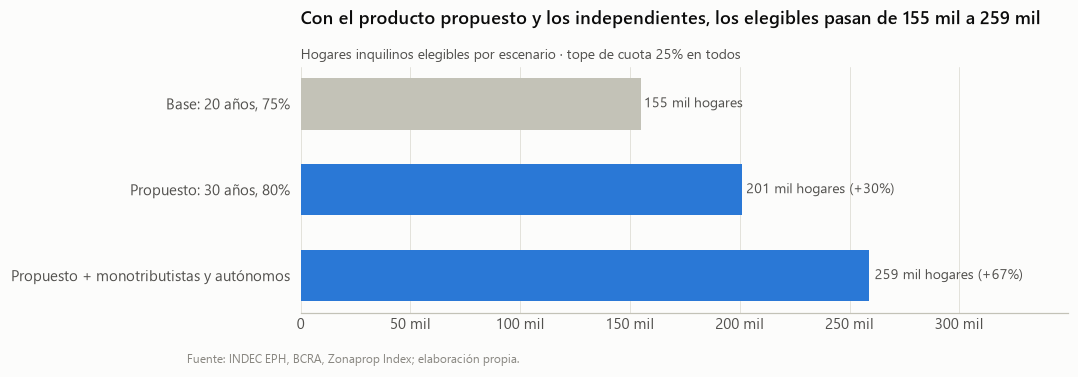

,hogares elegibles,% de inquilinos,vs base
"Base: 20 años, 75%","154,793.14",12.44,0.00
"Propuesto: 30 años, 80%","200,951.53",16.14,29.82
Propuesto + monotributistas y autónomos,"258,891.05",20.80,67.25


In [5]:
prop = base.con(plazo_anios=30, ltv=0.80)
escenarios = {
    "Base: 20 años, 75%": evaluar(h, m, base),
    "Propuesto: 30 años, 80%": evaluar(h, m, prop),
    "Propuesto + monotributistas y autónomos": evaluar(h, m, prop.con(acepta_independientes=True)),
}
tabla = pd.DataFrame({k: {"hogares elegibles": e.peso[e.elegible].sum(), "% de inquilinos": 100 * e.peso[e.elegible].sum() / e.peso.sum()} for k, e in escenarios.items()}).T
tabla["vs base"] = 100 * (tabla["hogares elegibles"] / tabla["hogares elegibles"].iloc[0] - 1)
fig, ax = plt.subplots(figsize=(9, 2.9))
bars = ax.barh(tabla.index[::-1], tabla["hogares elegibles"][::-1], color=[viz.BLUE, viz.BLUE, viz.CONTEXT_GRAY], height=0.6)
for bar, (idx, r) in zip(bars, tabla[::-1].iterrows()):
    extra = "" if idx.startswith("Base") else f" (+{fmt_pct(r['vs base'], 0)})"
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2, f"{fmt_cantidad(r['hogares elegibles'])} hogares{extra}", va="center", fontsize=9, color=viz.INK_2)
ax.xaxis.set_major_formatter(viz.EJE_CANTIDAD)
ax.set_xlim(0, tabla["hogares elegibles"].max() * 1.35)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_title(f"Con el producto propuesto y los independientes, los elegibles pasan de {fmt_cantidad(tabla['hogares elegibles'].iloc[0])} a {fmt_cantidad(tabla['hogares elegibles'].iloc[-1])}")
viz.subtitle(ax, "Hogares inquilinos elegibles por escenario · tope de cuota 25% en todos")
viz.source(fig, "INDEC EPH, BCRA, Zonaprop Index; elaboración propia.")
viz.save(fig, "04_escenarios_producto")
plt.show()
tabla

**Lectura:** el producto propuesto (**30 años, 80% financiado, cuota hasta 25%**) lleva los elegibles de 155 mil a **201 mil hogares** (+30%). Si además se aceptan ingresos de **monotributistas y autónomos con aportes**, llegan a **259 mil** (+67%), como línea separada con su propia política de riesgo (notebook 05).

## 4. Segmentos de "casi elegibles"
Hogares no elegibles cuyo ingreso cubre **al menos el 60% del ingreso requerido** y cumplen la edad: son el mercado a desarrollar.

Casi elegibles: 351 mil hogares · k elegido = 3 · silhouette = {3: 0.22, 4: 0.25, 5: 0.23, 6: 0.26}


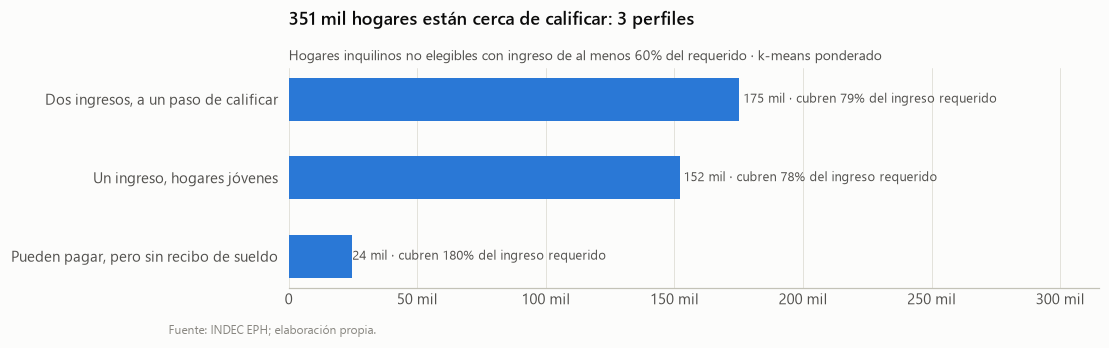

segmento,0,1,2
nombre,"Dos ingresos, a un paso de calificar","Un ingreso, hogares jóvenes","Pueden pagar, pero sin recibo de sueldo"
hogares,"174,936.92","151,981.56","24,493.50"
muestra_hogares,269.00,387.00,30.00
ingreso_mediano,"3,862,285.93","2,635,981.49","7,105,689.24"
cobertura_mediana,0.79,0.78,1.80
edad_mediana,43.00,35.00,39.00
miembros_mediana,3.00,2.00,2.00
pct_formal,73.21,53.70,0.00
pct_2_perceptores,95.18,33.97,55.25
pct_caba,39.38,29.93,22.64


In [6]:
import export_results
casi = A.casi_elegibles(ev)
seg, perfil, sinfo = A.segmentar(casi)
perfil.insert(0, "nombre", perfil.index.map(export_results.nombrar_segmentos(perfil)))
print(f"Casi elegibles: {fmt_hogares(casi.peso.sum())} · k elegido = {sinfo['k_optimo']} · silhouette = { {k: round(v, 2) for k, v in sinfo['silhouette'].items()} }")
fig, ax = plt.subplots(figsize=(9.5, 2.6))
p = perfil.sort_values("hogares")
bars = ax.barh(p.nombre, p.hogares, color=viz.BLUE, height=0.55)
for bar, r in zip(bars, p.itertuples()):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2, f"{fmt_cantidad(r.hogares)} · cubren {fmt_pct(100 * r.cobertura_mediana, 0)} del ingreso requerido", va="center", fontsize=8.5, color=viz.INK_2)
ax.set_xlim(0, p.hogares.max() * 1.8)
ax.xaxis.set_major_formatter(viz.EJE_CANTIDAD)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_title(f"{fmt_cantidad(casi.peso.sum())} hogares están cerca de calificar: {len(p)} perfiles")
viz.subtitle(ax, "Hogares inquilinos no elegibles con ingreso de al menos 60% del requerido · k-means ponderado")
viz.source(fig, "INDEC EPH; elaboración propia.")
viz.save(fig, "04_segmentos")
plt.show()
perfil.T

**Perfiles** (segmentación exploratoria: silhouette ≈ 0,22 indica estructura débil; se eligió el mayor k con al menos 30 hogares encuestados por grupo. Sirven como guía comercial, no como grupos rígidos):

| Perfil | Hogares | Qué los destraba |
|---|---|---|
| **Dos ingresos, a un paso de calificar** | 175 mil · edad mediana 43 · 73% con aportes · cubren 79% | Producto 30 años/80% y ahorro programado para el anticipo |
| **Un ingreso, hogares jóvenes** | 152 mil · edad mediana 35 · 54% con aportes · cubren 78% | Vivienda más chica o usada, plan de ahorro y sumar un segundo ingreso |
| **Pueden pagar, pero sin recibo de sueldo** | 24 mil · edad mediana 39 · 0% con aportes · cubren 180% | Validar ingresos de independientes: ya podrían pagar |

## 5. Escala del programa de fondeo

In [7]:
e = evaluar(h, m, prop)
prestamo_medio = np.average(e.prestamo_ars[e.elegible], weights=e.peso[e.elegible])
fgs = K["fgs"]["monto_ars"]
print(f"Préstamo medio de los elegibles con el producto propuesto: {fmt_monto(prestamo_medio)}")
print(f"El programa ({fmt_monto(fgs)}) financia ~{fmt_cantidad(fgs / prestamo_medio)} créditos")
print(f"Hogares elegibles con el producto propuesto: {fmt_cantidad(e.peso[e.elegible].sum())} → {fmt_decimal(e.peso[e.elegible].sum() / (fgs / prestamo_medio))} veces lo que financia el programa")

Préstamo medio de los elegibles con el producto propuesto: $ 121,6 millones
El programa ($ 2 billones) financia ~16 mil créditos
Hogares elegibles con el producto propuesto: 201 mil → 12,2 veces lo que financia el programa


**Lectura:** el programa alcanza para ~16 mil créditos (préstamo medio $ 121,6 millones), mientras que hay **201 mil hogares elegibles** con el producto propuesto (12 veces más). **La demanda elegible alcanza; lo que limita es el fondeo y la velocidad de colocación** (120 días): el banco puede ser selectivo y priorizar los perfiles de menor riesgo.

In [8]:
con.close()